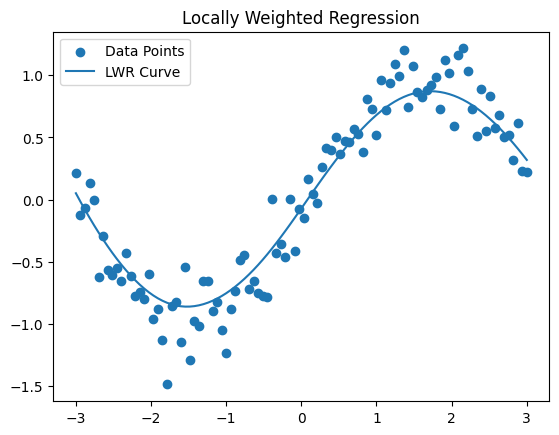

In [1]:
# Import numpy for numerical operations (arrays, math)
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt


# Set random seed so output is same every time
np.random.seed(0)

# Create 100 values between -3 and 3 (input data)
X = np.linspace(-3, 3, 100)

# Create output using sin function + small random noise
y = np.sin(X) + np.random.normal(0, 0.2, 100)

# Convert X into column format (required for calculations)
X = X.reshape(-1, 1)


# Function to calculate weights using Gaussian formula
def gaussian_weight(x_query, X, tau):
    # Calculate distance of all points from query point
    # Apply Gaussian formula to give higher weight to nearby points
    return np.exp(-np.sum((X - x_query)**2, axis=1) / (2 * tau**2))


# Function to perform Locally Weighted Regression
def locally_weighted_regression(X, y, tau):
    y_pred = []  # Empty list to store predicted values

    # Loop through each data point (we predict for every point)
    for x_query in X:

        # Step 1: Calculate weights for current query point
        W = gaussian_weight(x_query, X, tau)

        # Step 2: Convert weights into diagonal matrix
        W_matrix = np.diag(W)

        # Step 3: Add bias (1 column) to X for equation (y = mx + c)
        X_b = np.hstack((np.ones((X.shape[0], 1)), X))

        # Step 4: Calculate theta (parameters) using weighted formula
        theta = np.linalg.inv(X_b.T @ W_matrix @ X_b) @ (X_b.T @ W_matrix @ y)

        # Step 5: Add bias term to query point
        x_query_b = np.array([1, x_query[0]])

        # Step 6: Predict output using theta
        y_q = x_query_b @ theta

        # Store predicted value
        y_pred.append(y_q)

    # Convert list to array and return
    return np.array(y_pred)


# Set tau (controls how much nearby points matter)
tau = 0.5

# Apply LWR to get predicted values
y_lwr = locally_weighted_regression(X, y, tau)


# Plot original data points (scatter plot)
plt.scatter(X, y, label="Data Points")

# Plot LWR predicted curve (line)
plt.plot(X, y_lwr, label="LWR Curve")

# Add title to graph
plt.title("Locally Weighted Regression")

# Show legend (labels)
plt.legend()

# Display the graph
plt.show()